# 🏋️ Exercise Dataset — анализ пульса

Встроенный датасет seaborn **`exercise`**: как меняется **пульс** у людей при разных видах активности (**rest / walking / running**) и разных диетах (**no fat / low fat**), измеренный в 3 момента времени (**1, 15, 30 минут**).

**Столбцы:**
- `id` — номер участника
- `diet` — диета (no fat / low fat)
- `pulse` — пульс (удары/мин)
- `time` — момент измерения (1 min / 15 min / 30 min)
- `kind` — вид активности (rest / walking / running)

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

df = sns.load_dataset('exercise')
df.head()

,Unnamed: 0,id,diet,pulse,time,kind
0,0,1,low fat,85,1 min,rest
1,1,1,low fat,85,15 min,rest
2,2,1,low fat,88,30 min,rest
3,3,2,low fat,90,1 min,rest
4,4,2,low fat,92,15 min,rest


## 1. Обзор данных

In [12]:
print('Размер:', df.shape)
print('\nВиды активности:', df['kind'].unique())
print('Диеты:', df['diet'].unique())
print('Моменты времени:', df['time'].unique())

df.describe()

Размер: (90, 6)

Виды активности: ['rest', 'walking', 'running']
Categories (3, object): ['rest', 'walking', 'running']
Диеты: ['low fat', 'no fat']
Categories (2, object): ['no fat', 'low fat']
Моменты времени: ['1 min', '15 min', '30 min']
Categories (3, object): ['1 min', '15 min', '30 min']


,Unnamed: 0,id,pulse
count,90.000000,90.000000,90.000000
mean,44.500000,15.500000,99.700000
std,26.124701,8.703932,14.858471
min,0.000000,1.000000,80.000000
25%,22.250000,8.000000,90.250000
50%,44.500000,15.500000,96.000000
75%,66.750000,23.000000,103.000000
max,89.000000,30.000000,150.000000


## 2. Как меняется пульс со временем при разной активности

Главный вопрос: у бегунов пульс растёт со временем, а у отдыхающих — нет?

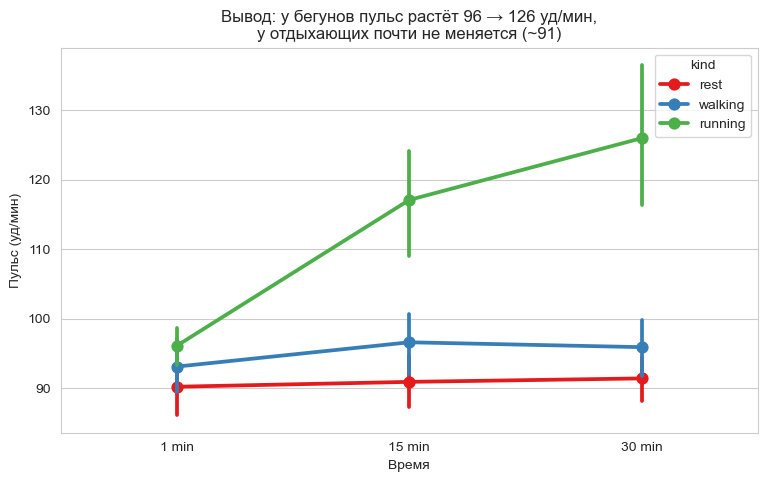

In [13]:
plt.figure(figsize=(9, 5))
sns.pointplot(data=df, x='time', y='pulse', hue='kind', palette='Set1')
plt.title('Вывод: у бегунов пульс растёт 96 → 126 уд/мин,\n'
          'у отдыхающих почти не меняется (~91)', fontsize=12)
plt.xlabel('Время')
plt.ylabel('Пульс (уд/мин)')
plt.show()

## 3. Распределение пульса по видам активности (boxplot)

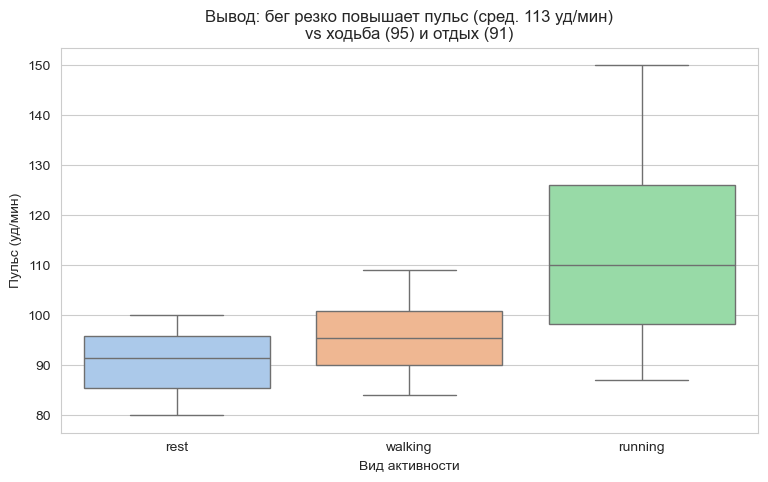

In [14]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='kind', y='pulse', hue='kind', palette='pastel', legend=False)
plt.title('Вывод: бег резко повышает пульс (сред. 113 уд/мин)\n'
          'vs ходьба (95) и отдых (91)', fontsize=12)
plt.xlabel('Вид активности')
plt.ylabel('Пульс (уд/мин)')
plt.show()

## 4. Влияет ли диета? (сравнение по диете и активности)

`catplot` с разбивкой по диете — отдельная панель для каждой диеты.

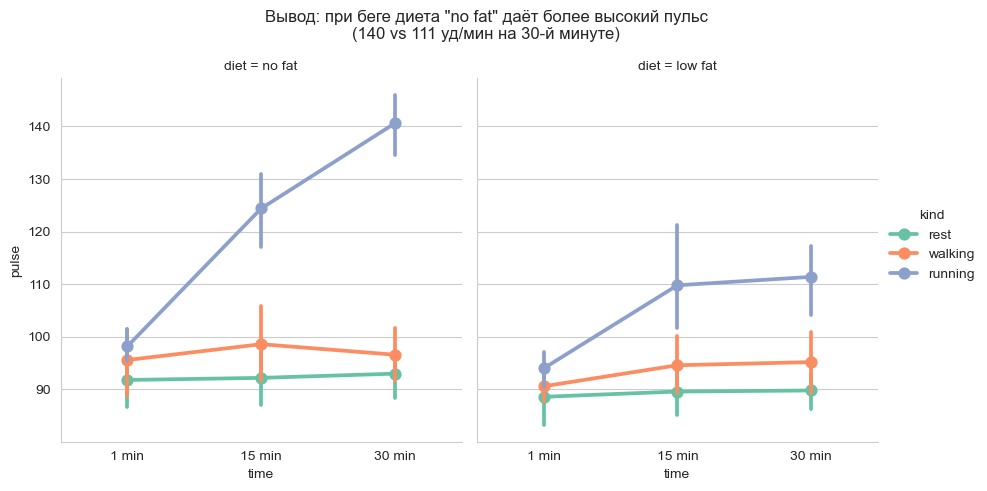

In [15]:
g = sns.catplot(data=df, x='time', y='pulse', hue='kind',
                col='diet', kind='point', palette='Set2', height=4.5, aspect=1)
g.fig.suptitle('Вывод: при беге диета "no fat" даёт более высокий пульс\n'
               '(140 vs 111 уд/мин на 30-й минуте)', y=1.08, fontsize=12)
plt.show()

## 5. Средний пульс — сводная таблица

Группируем по активности и времени.

time     1 min  15 min  30 min
kind                          
rest      90.2    90.9    91.4
walking   93.1    96.6    95.9
running   96.1   117.1   126.0


/var/folders/ph/mnfl_fnx1lxfylcfnh1hmt1c0000gn/T/ipykernel_54090/1547055757.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='pulse', index='kind', columns='time', aggfunc='mean')


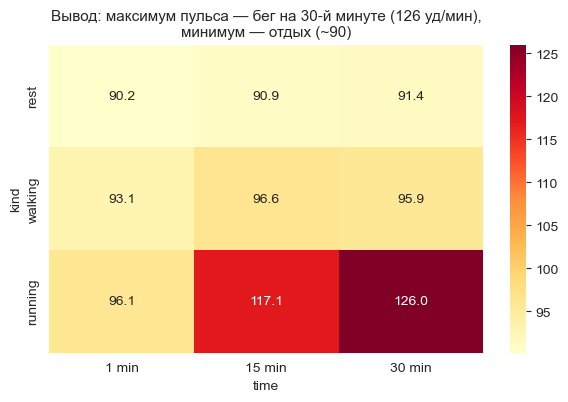

In [16]:
pivot = df.pivot_table(values='pulse', index='kind', columns='time', aggfunc='mean')
print(pivot)

plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Вывод: максимум пульса — бег на 30-й минуте (126 уд/мин),\n'
          'минимум — отдых (~90)', fontsize=11)
plt.show()